Paso 1: Configuración del Entorno y Librerías
- Descripción: "Importamos el stack tecnológico necesario para el procesamiento de datos y la generación de gráficos, asegurando que todas las herramientas analíticas estén disponibles."

In [ ]:
### Inicialización del Proyecto
# Gestión de dependencias y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración para gráficos integrados
%matplotlib inline

Paso 2: Ingesta del Dataset Original
- Descripción: "Cargamos el archivo CSV crudo de ventas. Es el primer paso del proceso ETL (Extracción, Transformación y Carga), donde traemos los datos del sistema de gestión para empezar a auditarlos."

In [8]:
# Definimos la ruta del archivo
ruta_ventas = "../data/SalesFINAL12312016.csv"

# Leemos el archivo asegurando el delimitador correcto
df_ventas_crudo = pd.read_csv(ruta_ventas, sep=',')

# Verificamos rápidamente la carga
print(f"Dimensiones del dataset: {df_ventas_crudo.shape[0]} filas y {df_ventas_crudo.shape[1]} columnas.")
df_ventas_crudo.head()

Dimensiones del dataset: 1048575 filas y 14 columnas.


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/1/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,1/2/2016,750,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,1/3/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,1/8/2016,750,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,1/9/2016,375,1,0.79,12546,JIM BEAM BRANDS COMPANY


Paso 3: Estandarización de Nomenclatura (Renombrado)
- Descripción: "Para que el proyecto sea comprensible para todo el equipo y se alinee con el lenguaje de negocio, traducimos los nombres de las columnas del inglés al español técnico. Esto también prepara el terreno para la creación del modelo estrella en la base de datos."

In [9]:
# Diccionario de traducción para las columnas
mapeo_nombres = {
    'InventoryId': 'ID_Inventario',
    'Store': 'ID_Sucursal',
    'Brand': 'ID_Marca',
    'Description': 'Descripcion_Articulo',
    'Size': 'Presentacion',
    'SalesQuantity': 'Unidades_Vendidas',
    'SalesDollars': 'Ingreso_Total',
    'SalesPrice': 'Precio_Unitario',
    'SalesDate': 'Fecha_Venta',
    'Volume': 'Volumen',
    'Classification': 'Tipo_Producto',
    'VendorName': 'Proveedor'
}

# Aplicamos el cambio
df_ventas = df_ventas_crudo.rename(columns=mapeo_nombres)
print("Columnas actualizadas correctamente.")

Columnas actualizadas correctamente.


Paso 4: Verificación de Calidad y Diagnóstico
- Descripción: "Realizamos una inspección técnica para detectar valores nulos y verificar los tipos de datos asignados automáticamente. Este diagnóstico es fundamental para identificar qué columnas requieren limpieza antes de realizar cálculos matemáticos."

In [10]:
# Informe de nulos y tipos de datos
print("Análisis de valores faltantes:")
print(df_ventas.isnull().sum())

print("\nTipos de datos detectados:")
print(df_ventas.dtypes)

Análisis de valores faltantes:
ID_Inventario           0
ID_Sucursal             0
ID_Marca                0
Descripcion_Articulo    0
Presentacion            0
Unidades_Vendidas       0
Ingreso_Total           0
Precio_Unitario         0
Fecha_Venta             0
Volumen                 0
Tipo_Producto           0
ExciseTax               0
VendorNo                0
Proveedor               0
dtype: int64

Tipos de datos detectados:
ID_Inventario               str
ID_Sucursal               int64
ID_Marca                  int64
Descripcion_Articulo        str
Presentacion                str
Unidades_Vendidas         int64
Ingreso_Total           float64
Precio_Unitario         float64
Fecha_Venta                 str
Volumen                   int64
Tipo_Producto             int64
ExciseTax               float64
VendorNo                  int64
Proveedor                   str
dtype: object


Paso 5: Limpieza de Nulos e Integridad
- Descripción: "Eliminamos los registros que carecen de información crítica como el ID de producto o la cantidad vendida. Al ser datos esenciales para el seguimiento del inventario, su ausencia invalidaría cualquier conclusión analítica."

In [11]:
# Eliminamos filas donde falten datos clave para el negocio
df_ventas = df_ventas.dropna(subset=['ID_Inventario', 'Unidades_Vendidas', 'Precio_Unitario'])

# Verificamos que ya no existan nulos en esas columnas
print(f"Registros restantes tras la limpieza de nulos: {len(df_ventas)}")

Registros restantes tras la limpieza de nulos: 1048575


Paso 6: Eliminación de Registros Duplicados
- Descripción: "Buscamos y removemos filas idénticas que podrían haber sido generadas por errores en el sistema de carga. Mantener registros únicos garantiza que no inflemos los ingresos ni restemos stock de forma errónea."

In [12]:
# Contamos y eliminamos duplicados
duplicados = df_ventas.duplicated().sum()
print(f"Se eliminaron {duplicados} registros duplicados.")

df_ventas = df_ventas.drop_duplicates()

Se eliminaron 0 registros duplicados.


Paso 7: Ingeniería de Atributos (Cálculo de Packs)
- Descripción: "Extraemos información oculta en la columna de presentación para identificar productos que se venden en paquetes múltiples (ej. 2 Pk). Esto permite calcular el stock real a nivel de unidades individuales, mejorando la precisión del inventario."

In [13]:
def extraer_unidades_pack(texto):
    if pd.isna(texto):
        return 1
    # Buscamos números seguidos de 'Pk'
    match = re.search(r'(\d+)\s*Pk', str(texto))
    return int(match.group(1)) if match else 1

# Creamos la nueva columna técnica
df_ventas['Unidades_por_Empaque'] = df_ventas['Presentacion'].apply(extraer_unidades_pack)

Paso 8: Formateo Temporal y Numérico
- Descripción: "Convertimos las fechas de texto a formato de tiempo real (datetime) y nos aseguramos de que los valores monetarios sean numéricos. Esto habilita la creación de análisis de tendencias por mes y año en Power BI."

In [14]:
# Transformación de fechas
df_ventas['Fecha_Venta'] = pd.to_datetime(df_ventas['Fecha_Venta'])

# Creación de dimensiones temporales simples
df_ventas['Mes'] = df_ventas['Fecha_Venta'].dt.month
df_ventas['Anio'] = df_ventas['Fecha_Venta'].dt.year

# Asegurar formato decimal en ingresos
df_ventas['Ingreso_Total'] = pd.to_numeric(df_ventas['Ingreso_Total'], errors='coerce')

Paso 9: Exportación de Datos Curados
- Descripción: "Finalmente, guardamos el dataset limpio en un nuevo archivo CSV. Este archivo será nuestra 'fuente de verdad' para la base de datos SQL y el reporte final, garantizando que trabajamos con datos de alta calidad."

In [17]:
# Guardamos en la carpeta de datos
df_ventas.to_csv("../data/DatosProcesados/Ventas_Limpias_Final.csv", index=False)
print("¡Proceso finalizado! Archivo listo para la siguiente fase.")

¡Proceso finalizado! Archivo listo para la siguiente fase.


Paso de Carga de Datos Curados
- Descripción: "Una vez finalizado el proceso de limpieza y exportación, procedemos a reingresar el dataset procesado (Ventas_Limpias_Final.csv) al entorno del Notebook. Este paso es fundamental para validar que el archivo guardado mantiene la integridad de los datos y para asegurar que los análisis estadísticos y visualizaciones siguientes se realicen exclusivamente sobre información depurada y normalizada."

In [19]:
# Definimos la ruta del archivo que guardamos en el paso 9
ruta_archivo_limpio = "../data/DatosProcesados/Ventas_Limpias_Final.csv"

# Cargamos el dataframe final
df_ventas_final = pd.read_csv(ruta_archivo_limpio)

# Validamos que la carga sea correcta y que las fechas mantengan el formato si es necesario
df_ventas_final['Fecha_Venta'] = pd.to_datetime(df_ventas_final['Fecha_Venta'])

print(f"Dataset listo para análisis. Total de registros: {len(df_ventas_final)}")
df_ventas_final.head(3)

Dataset listo para análisis. Total de registros: 1048575


,ID_Inventario,ID_Sucursal,ID_Marca,Descripcion_Articulo,Presentacion,Unidades_Vendidas,Ingreso_Total,Precio_Unitario,Fecha_Venta,Volumen,Tipo_Producto,ExciseTax,VendorNo,Proveedor,Unidades_por_Empaque,Mes,Anio
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-01,750,1,0.79,12546,JIM BEAM BRANDS COMPANY,1,1,2016
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2016-01-02,750,1,1.57,12546,JIM BEAM BRANDS COMPANY,1,1,2016
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2016-01-03,750,1,0.79,12546,JIM BEAM BRANDS COMPANY,1,1,2016


Paso 10: Análisis Descriptivo de Validación
- Descripción: "Para finalizar el proceso, realizamos una exploración estadística rápida de los datos ya limpios. El objetivo es verificar la distribución de las ventas e identificar a los proveedores con mayor movimiento comercial. Esto nos permite asegurar que el dataset es coherente y está listo para ser explotado en Power BI."

Resumen de métricas clave:


,Unidades_Vendidas,Ingreso_Total,Precio_Unitario
count,1.048575e+06,1.048575e+06,1.048575e+06
mean,2.337619e+00,3.160420e+01,1.543162e+01
std,3.511492e+00,6.570249e+01,1.404967e+01
min,1.000000e+00,4.900000e-01,4.900000e-01
25%,1.000000e+00,1.099000e+01,8.990000e+00
50%,1.000000e+00,1.799000e+01,1.299000e+01
75%,2.000000e+00,3.199000e+01,1.899000e+01
max,4.320000e+02,1.327997e+04,4.999990e+03


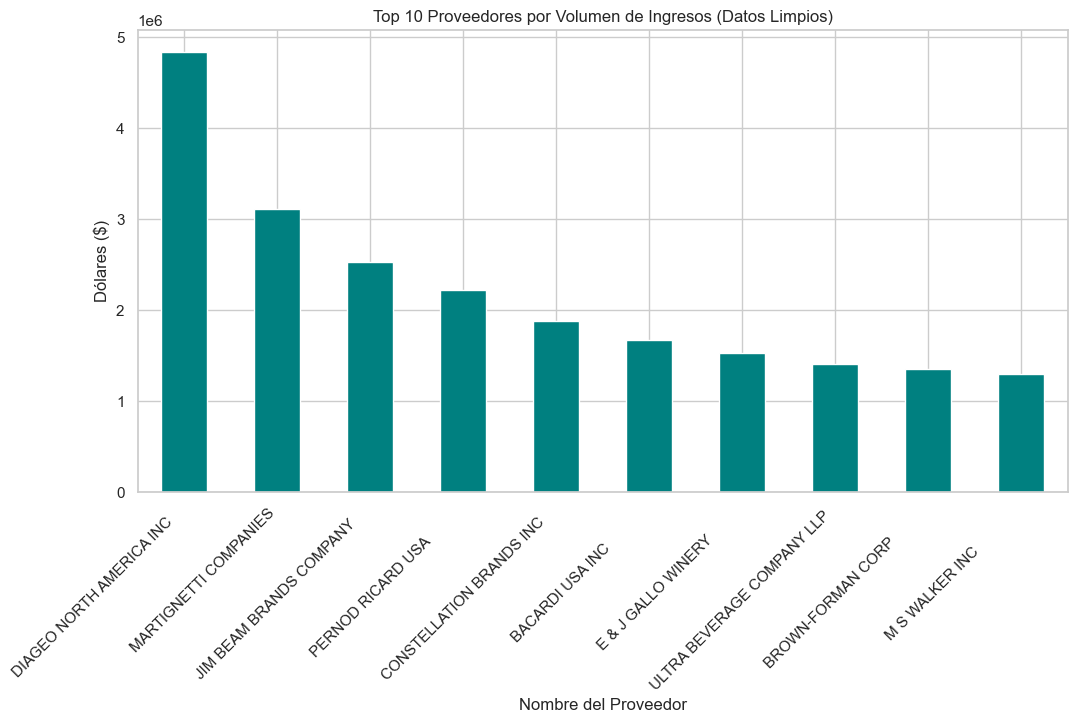

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# 1. Resumen estadístico de las ventas
print("Resumen de métricas clave:")
display(df_ventas[['Unidades_Vendidas', 'Ingreso_Total', 'Precio_Unitario']].describe())

# 2. Visualización: Top 10 Proveedores por Ingresos
plt.figure(figsize=(12, 6))
top_proveedores = df_ventas.groupby('Proveedor')['Ingreso_Total'].sum().sort_values(ascending=False).head(10)
top_proveedores.plot(kind='bar', color='teal')

plt.title('Top 10 Proveedores por Volumen de Ingresos (Datos Limpios)')
plt.ylabel('Dólares ($)')
plt.xlabel('Nombre del Proveedor')
plt.xticks(rotation=45, ha='right')
plt.show()

Paso 11: Análisis de Tendencia Temporal de Ventas
- Descripción: "Para validar la consistencia de los datos a lo largo del tiempo, generamos un gráfico de líneas que muestra la evolución diaria de los ingresos. Este análisis permite identificar picos de demanda estacionales o posibles caídas en el registro de datos, asegurando que la serie temporal esté completa para el modelo de inteligencia de negocios."

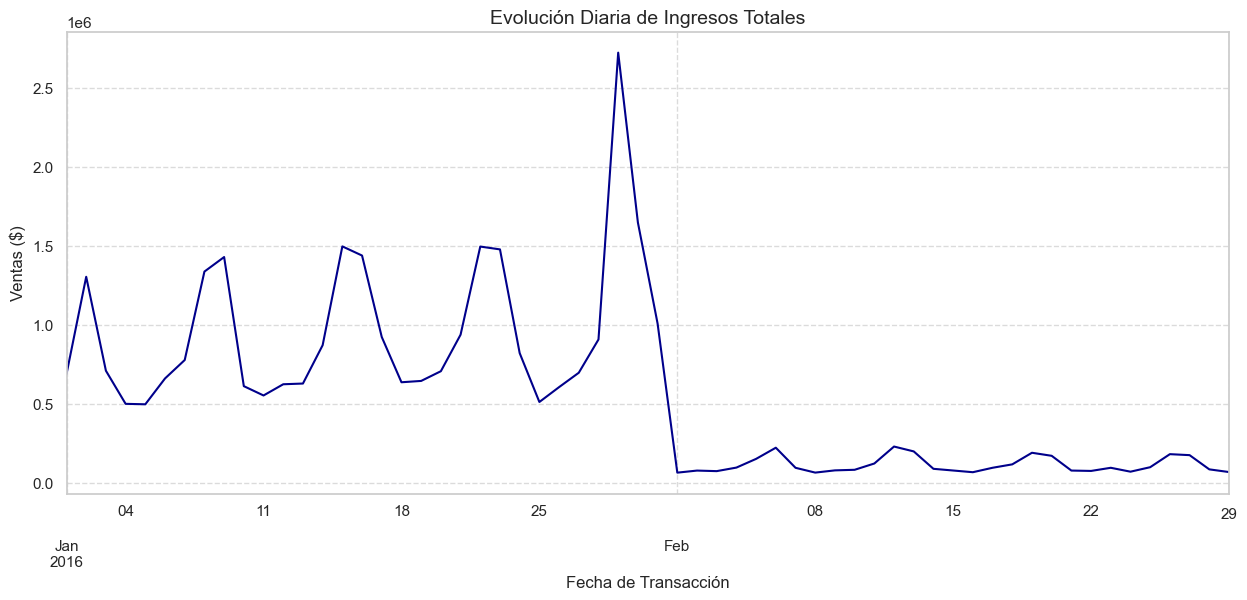

In [21]:
# Agrupamos la venta total por fecha
tendencia_ventas = df_ventas.groupby('Fecha_Venta')['Ingreso_Total'].sum()

# Configuración del gráfico
plt.figure(figsize=(15, 6))
tendencia_ventas.plot(kind='line', color='darkblue', linewidth=1.5)

plt.title('Evolución Diaria de Ingresos Totales', fontsize=14)
plt.xlabel('Fecha de Transacción', fontsize=12)
plt.ylabel('Ventas ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Paso 12: Identificación de Proveedores Estratégicos (Top Ventas)
- Descripción: "Realizamos una segmentación de proveedores para identificar a los socios comerciales con mayor volumen de movimiento. Filtramos aquellos con una cantidad de unidades vendidas superior a 10,000 para enfocarnos en los actores críticos de la cadena de suministro. Este paso es fundamental para priorizar futuras integraciones de stock en el sistema."

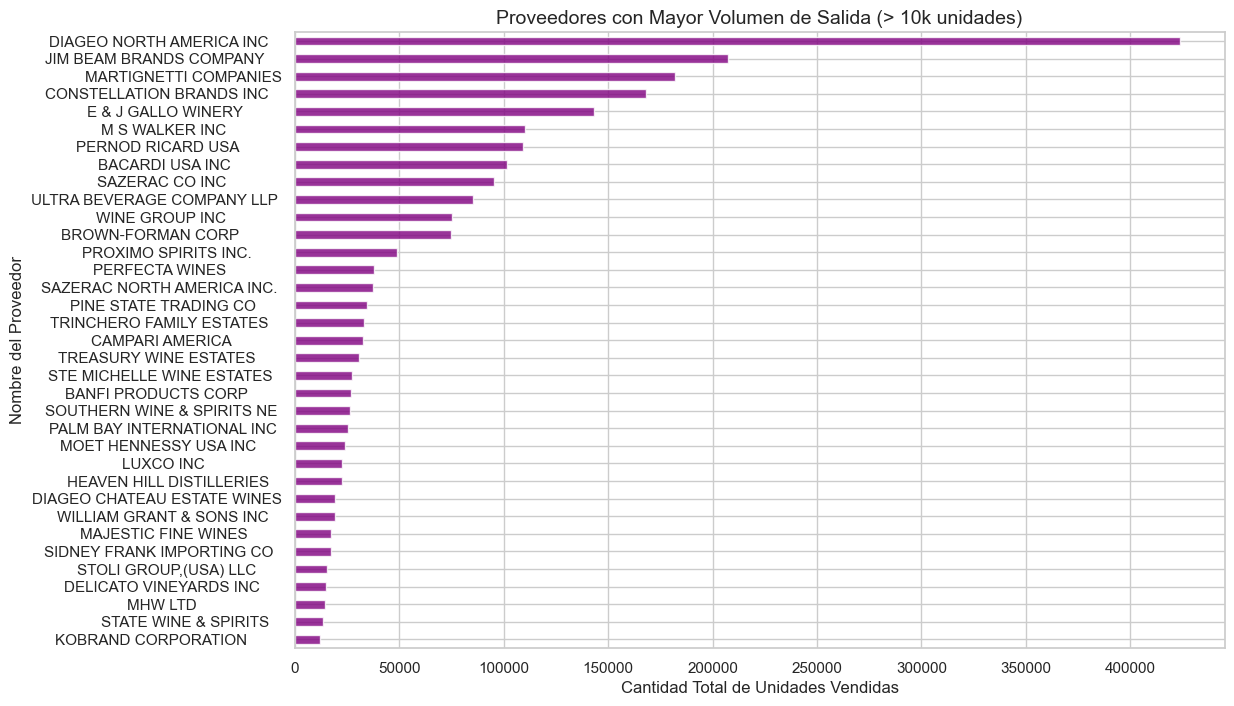

In [22]:
# Agrupamos por proveedor y sumamos las unidades vendidas
ventas_por_proveedor = df_ventas.groupby('Proveedor')['Unidades_Vendidas'].sum().sort_values(ascending=True)

# Filtramos proveedores con alto volumen (más de 10,000 unidades)
proveedores_criticos = ventas_por_proveedor[ventas_por_proveedor > 10000]

# Configuración del gráfico de barras horizontales (más fácil de leer nombres largos)
plt.figure(figsize=(12, 8))
proveedores_criticos.plot(kind='barh', color='purple', alpha=0.8)

plt.title('Proveedores con Mayor Volumen de Salida (> 10k unidades)', fontsize=14)
plt.xlabel('Cantidad Total de Unidades Vendidas', fontsize=12)
plt.ylabel('Nombre del Proveedor', fontsize=12)
plt.show()